In [25]:
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import metpy
import project
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from wrf import getvar, interplevel

In [26]:
file_path = 'wrf_data\index_1\wrfout_d01_2025-07-25_20_00_00.nc'
ncfile = Dataset(file_path)
ds = xr.open_dataset(file_path)
crs = project.get_projection(ds)

In [27]:
filename = file_path.split('\\')[-1].split('/')[-1]
parts = filename.split('_')
month_day = parts[2][5:] 
hour = parts[3]           
result = f"{month_day}_{hour}"

In [28]:
# --- 1. 提取所有必要的 3D 诊断变量 ---
pres = getvar(ncfile, "pressure")      # 全层气压 (hPa)
z = getvar(ncfile, "z", units="dm")    # 全层位势高度 (dm)
tc = getvar(ncfile, "tc")              # 全层摄氏温度 (C)
ua = getvar(ncfile, "ua")              # 全层 U 风分量
va = getvar(ncfile, "va")              # 全层 V 风分量

# --- 2. 计算 500 hPa 层面 ---
z_500  = interplevel(z, pres, 500)
t_500  = interplevel(tc, pres, 500)
ua_500 = interplevel(ua, pres, 500)
va_500 = interplevel(va, pres, 500)

# --- 3. 计算 850 hPa 层面 ---
z_850  = interplevel(z, pres, 850)
t_850  = interplevel(tc, pres, 850)
ua_850 = interplevel(ua, pres, 850)
va_850 = interplevel(va, pres, 850)

In [29]:
lon_2d,lat_2d = z_500['XLONG'], z_500['XLAT']



In [30]:
sigma = 2  # 高斯核宽度，越大越平滑
z_500_smooth = gaussian_filter(z_500.values, sigma=sigma)
t_500_smooth = gaussian_filter(t_500.values, sigma=sigma)

z_850_smooth = gaussian_filter(z_850.values, sigma=sigma)
t_850_smooth = gaussian_filter(t_850.values, sigma=sigma)

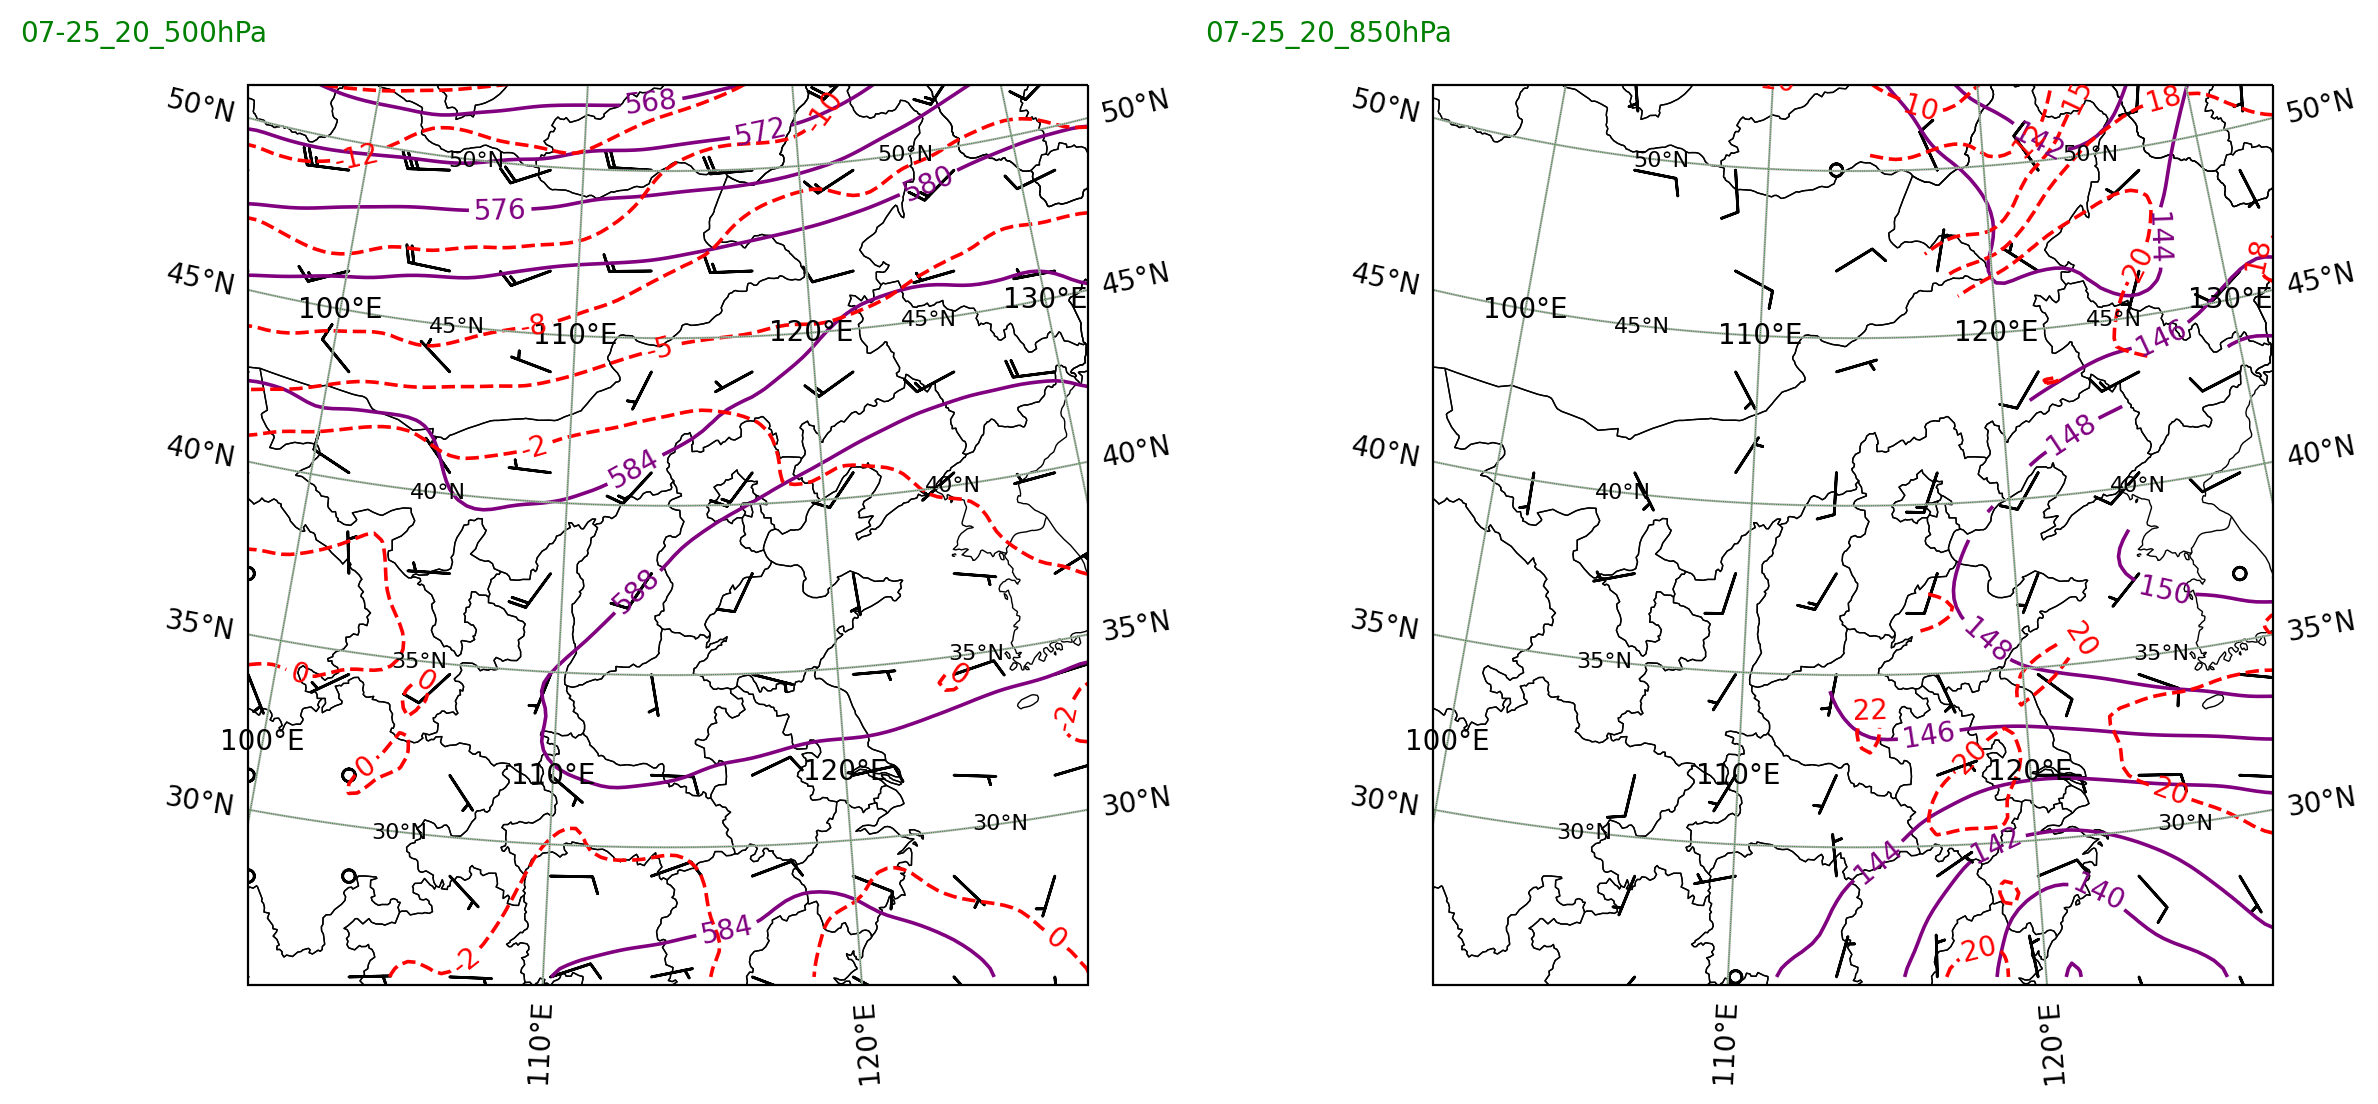

In [40]:
fig,axarray = plt.subplots(nrows=1,ncols=2,figsize=(12,6),subplot_kw={'projection': crs},dpi=200)
axlist = axarray.flatten()

for ax in axlist:
    project.plot_background(lon_2d[0,0], lon_2d[0,-1], lat_2d[0,0], lat_2d[-1,0], ax)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,      # 打开经纬度标签
        linewidth=0.3,
        linestyle=':',
        color='green',
        x_inline=False,       # 关闭经线
        y_inline=True,       # 关闭纬线
    )
    gl.top_labels = False      # 关闭顶部刻度
    gl.right_labels = False   # 关闭右侧刻度
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 8}


# 使用 contour 绘制线条，支持 linewidths
cf1 = axlist[0].contour(lon_2d, lat_2d, z_500_smooth, 
                        colors='purple', 
                        transform=ccrs.PlateCarree(), 
                        linewidths=1.3)

ct1 = axlist[0].contour(lon_2d, lat_2d, t_500_smooth,
                        colors='red', 
                        transform=ccrs.PlateCarree(),
                        linestyles='--', 
                        linewidths=1.3)
axlist[0].clabel(ct1, inline=True, fontsize=10, fmt='%1.0f')

# 建议：添加等值线标签
axlist[0].clabel(cf1, inline=True, fontsize=10, fmt='%1.0f')
axlist[0].text(
    83, 50,    # 经度、纬度（你可以自己微调）
    f'{result}_500hPa',
    fontsize=10, color='green',
    transform=ccrs.PlateCarree()  # ✅ 关键！
)

####################风场####################
skip = 12  # 抽点因子，用于减少风场的密度，避免过密

axlist[0].barbs(
    lon_2d[::skip, ::skip].values,    # 经纬度（抽点，避免太密）
    lat_2d[::skip, ::skip].values,
    ua_500[::skip, ::skip].values,      # U风
    va_500[::skip, ::skip].values,      # V风
    transform=ccrs.PlateCarree(),
    length=5.5,          # 风标长度
    linewidth=1,       # 线条粗细
    color='black'         # 颜色
)

cf2 = axlist[1].contour(lon_2d, lat_2d, z_850_smooth, 
                        colors='purple',
                        transform=ccrs.PlateCarree(), 
                        linewidths=1.3)
axlist[1].clabel(cf2, inline=True, fontsize=10, fmt='%1.0f')

ct2 = axlist[1].contour(lon_2d, lat_2d, t_850_smooth,
                        colors='red',
                        transform=ccrs.PlateCarree(),
                        linestyles='--', 
                        linewidths=1.3)
axlist[1].clabel(ct2, inline=True, fontsize=10, fmt='%1.0f')

axlist[1].barbs(
    lon_2d[::skip, ::skip].values,    # 经纬度（抽点，避免太密）
    lat_2d[::skip, ::skip].values,
    ua_850[::skip, ::skip].values,      # U风
    va_850[::skip, ::skip].values,      # V风
    transform=ccrs.PlateCarree(),
    length=5.5,          # 风标长度
    linewidth=1,       # 线条粗细
    color='black'         # 颜色
)
axlist[1].text(
    83, 50,   
    f'{result}_850hPa',
    fontsize=10, color='green',
    transform=ccrs.PlateCarree()  # ✅ 关键！
)

plt.tight_layout()
fig.savefig(f'{result}_500_850.png', dpi=200)
